          Date  Rented Bike Count  Rainfall
0   2017-12-01               9539       0.0
1   2017-12-02               8146       0.0
2   2017-12-03               7222       4.0
3   2017-12-04               8729       0.1
4   2017-12-05               8307       0.0
..         ...                ...       ...
360 2018-11-26              17162       0.0
361 2018-11-27              16282       0.0
362 2018-11-28              16524       0.0
363 2018-11-29              36297       0.0
364 2018-11-30              16297       0.0

[365 rows x 3 columns]


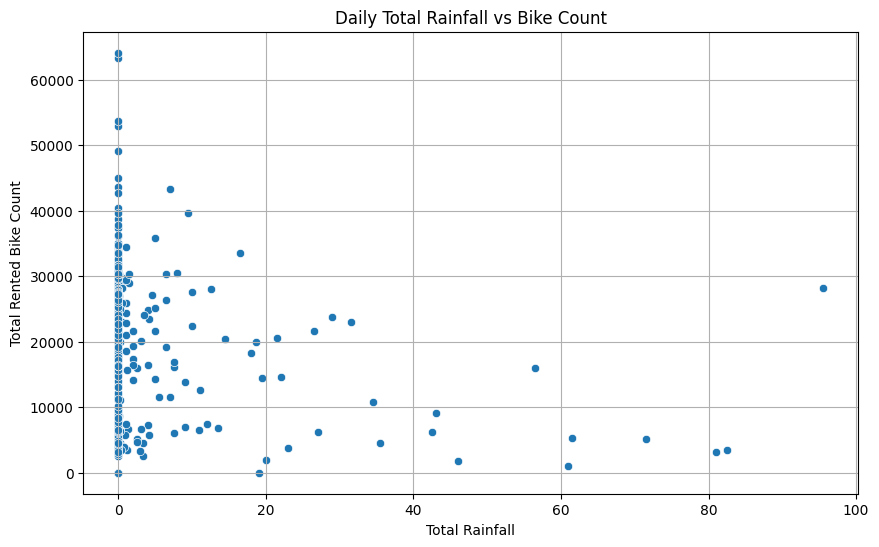

          Date  Rented Bike Count  Rainfall
0   2017-12-01               9539       0.0
1   2017-12-02               8146       0.0
2   2017-12-03               7222       4.0
3   2017-12-04               8729       0.1
4   2017-12-05               8307       0.0
..         ...                ...       ...
360 2018-11-26              17162       0.0
361 2018-11-27              16282       0.0
362 2018-11-28              16524       0.0
363 2018-11-29              36297       0.0
364 2018-11-30              16297       0.0

[365 rows x 3 columns]
일일 강수량과 대여량 상관계수: -0.16741111915863852


In [ ]:
#일일 총 강수량에 따른 대여량 분석 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')

# 전처리: 'Date' 컬럼을 날짜 형식으로 변환
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
#이상치 제거
df = df[df['Rainfall'] >= 0]

# 하루 동안의 대여량 합계와 강수량 합계
daily_df = df.groupby('Date').sum()
daily_df = daily_df[['Rented Bike Count', 'Rainfall']].reset_index()

# 그래프
plt.figure(figsize=(10, 6))
sns.scatterplot(data=daily_df, x='Rainfall', y='Rented Bike Count')
plt.title('Daily Total Rainfall vs Bike Count')
plt.xlabel('Total Rainfall')
plt.ylabel('Total Rented Bike Count')
plt.grid(True)
plt.show()

# 값
print(daily_df)

# 상관계수
print("일일 강수량과 대여량 상관계수:", daily_df.corr().loc['Rainfall', 'Rented Bike Count'])



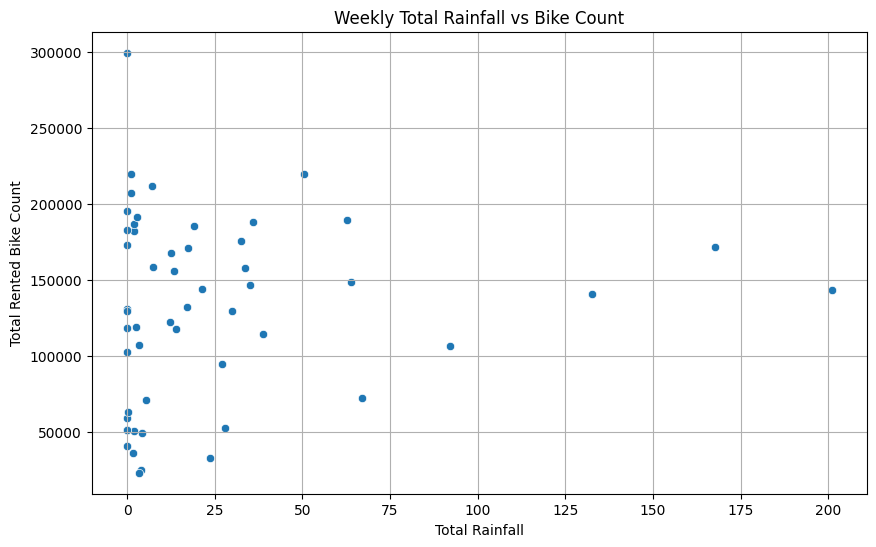

         Date  Rented Bike Count  Rainfall
0  2017-12-03              24907       4.0
1  2017-12-10              70953       5.5
2  2017-12-17              59032       0.0
3  2017-12-24              32796      23.6
4  2017-12-31              36063       1.7
5  2018-01-07              40562       0.0
6  2018-01-14              50503       2.1
7  2018-01-21              63352       0.2
8  2018-01-28              23203       3.3
9  2018-02-04             107402       3.4
10 2018-02-11              51424       0.0
11 2018-02-18              51524       0.0
12 2018-02-25              49415       4.1
13 2018-03-04              52373      28.0
14 2018-03-11             132331      17.0
15 2018-03-18              94984      27.0
16 2018-03-25             119395       2.5
17 2018-04-01             118475       0.0
18 2018-04-08             114386      38.8
19 2018-04-15             118021      14.0
20 2018-04-22             156245      13.5
21 2018-04-29             148968      64.0
22 2018-05-

In [51]:
# 주별 총 강수량에 따른 대여량 분석

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')

# 날짜 형식 변환
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# 결측값 제거
df = df.dropna(subset=['Rainfall', 'Rented Bike Count'])

# 이상치 제거 (강수량 음수 제거)
df = df[df['Rainfall'] >= 0]

# 주별 데이터 합계
weekly_df = df.resample('W', on='Date').sum()

# 필요한 컬럼만 선택
weekly_df = weekly_df[['Rented Bike Count', 'Rainfall']].reset_index()

# 그래프
plt.figure(figsize=(10, 6))
sns.scatterplot(data=weekly_df, x='Rainfall', y='Rented Bike Count')

plt.title('Weekly Total Rainfall vs Bike Count')
plt.xlabel('Total Rainfall')
plt.ylabel('Total Rented Bike Count')
plt.grid(True)
plt.show()

# 값 출력
print(weekly_df)

# 상관계수
print("주별 강수량과 대여량 상관계수:", weekly_df.corr(numeric_only=True).loc['Rainfall', 'Rented Bike Count'])

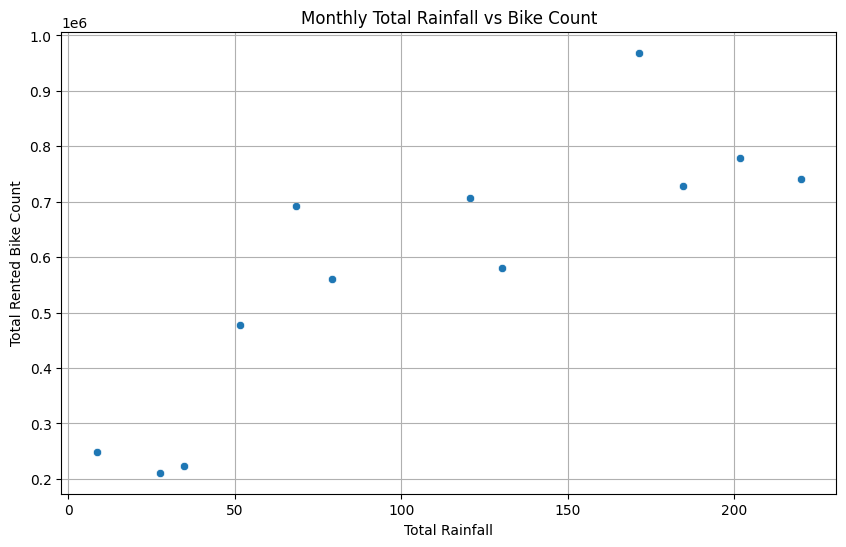

         Date  Rainfall  Rented Bike Count
0  2017-12-31      34.8             223751
1  2018-01-31       8.5             248119
2  2018-02-28      27.6             211195
3  2018-03-31      51.5             478241
4  2018-04-30     130.3             580470
5  2018-05-31     220.0             741459
6  2018-06-30     171.5             968872
7  2018-07-31     184.6             729144
8  2018-08-31     201.6             779364
9  2018-09-30      68.5             692546
10 2018-10-31     120.5             707502
11 2018-11-30      79.1             560312
월별 강수량과 대여량 상관계수: 0.8406398418337866


In [53]:
# 월별 총 강수량에 따른 대여량 분석

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')

# 날짜 형식 변환
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# 결측값 제거
df = df.dropna(subset=['Rainfall', 'Rented Bike Count'])

# 이상치 제거
df = df[df['Rainfall'] >= 0]

# 필요한 숫자 컬럼만 선택 후 월별 합계
monthly_df = df[['Date', 'Rainfall', 'Rented Bike Count']]

monthly_df = monthly_df.resample('ME', on='Date').sum()

# 인덱스 초기화
monthly_df = monthly_df.reset_index()

# 그래프
plt.figure(figsize=(10, 6))
sns.scatterplot(data=monthly_df, x='Rainfall', y='Rented Bike Count')

plt.title('Monthly Total Rainfall vs Bike Count')
plt.xlabel('Total Rainfall')
plt.ylabel('Total Rented Bike Count')
plt.grid(True)
plt.show()

# 값 출력
print(monthly_df)

# 상관계수
print("월별 강수량과 대여량 상관계수:",
      monthly_df[['Rainfall', 'Rented Bike Count']].corr().loc['Rainfall', 'Rented Bike Count'])